<a href="https://colab.research.google.com/github/Angel-crypt/face2emotion-AIML/blob/main/face2emotion_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [93]:
import os
import time
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

In [18]:
path = kagglehub.dataset_download("samithsachidanandan/human-face-emotions")

Using Colab cache for faster access to the 'human-face-emotions' dataset.


In [21]:
path_original = f"{path}/Data"
emociones_deseadas = ["Angry", "Happy", "Sad"]

## Crear dataset con las imagenes de las emociones a clasificar

In [85]:
# Crear una lista con las rutas de las imágenes de las emociones deseadas
datos = []
for emocion in emociones_deseadas:
    ruta_emocion = os.path.join(path_original, emocion)
    if os.path.exists(ruta_emocion):
        for imagen in os.listdir(ruta_emocion):
            # Guardamos la ruta completa de la imagen y su etiqueta (emoción)
            ruta_completa = os.path.join(ruta_emocion, imagen)
            datos.append({"Ruta": ruta_completa, "Emotion": emocion})

# Convertimos a DataFrame de Pandas
df_raw = pd.DataFrame(datos)

# Mezclar el dataset (shuffle)
df_raw = df_raw.sample(frac=1).reset_index(drop=True)

print(df_raw.head())

                                                Ruta Emotion
0  /kaggle/input/human-face-emotions/Data/Happy/2...   Happy
1  /kaggle/input/human-face-emotions/Data/Angry/8...   Angry
2  /kaggle/input/human-face-emotions/Data/Happy/3...   Happy
3  /kaggle/input/human-face-emotions/Data/Happy/9...   Happy
4  /kaggle/input/human-face-emotions/Data/Happy/2...   Happy


## Entender distribucion inicial

In [86]:
frecuency = df_raw['Emotion'].value_counts()
representation = (df_raw['Emotion'].value_counts(normalize=True) * 100).round(2)

resumen = pd.DataFrame({
    'Frecuencia': frecuency,
    'Representacion (%)': representation
})

print(f'Total de imágenes: {len(df_raw)}\n')
print(resumen)

Total de imágenes: 41140

         Frecuencia  Representacion (%)
Emotion                                
Happy         18439               44.82
Sad           12553               30.51
Angry         10148               24.67


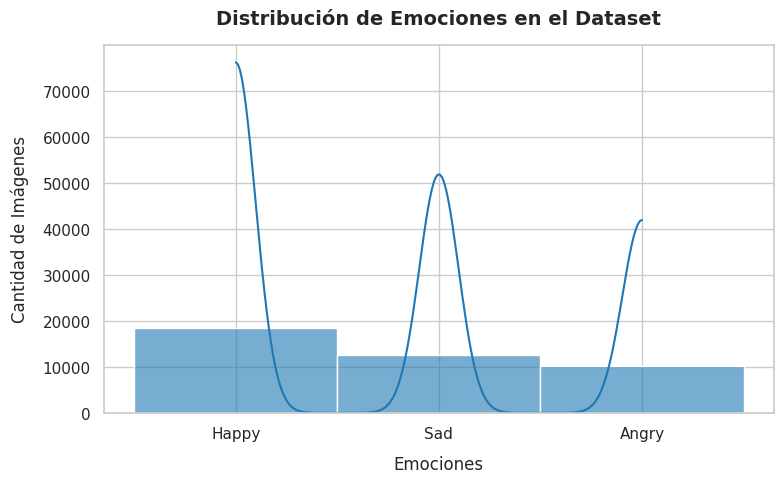

In [87]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

df_raw['Emotion_Num'] = df_raw['Emotion'].map({'Happy': 0, 'Sad': 1, 'Angry': 2})

sns.histplot(
    data=df_raw,
    x='Emotion_Num',
    kde=True,
    discrete=True,
    color='#1f77b4',
    alpha=0.6,
    ax=ax
)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Happy', 'Sad', 'Angry'])

ax.set_title("Distribución de Emociones en el Dataset", fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel("Emociones", fontsize=12, labelpad=10)
ax.set_ylabel("Cantidad de Imágenes", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

## Balancear clases recortando

In [88]:
# Cantidad mínima de imágenes
min_imgs = df_raw['Emotion'].value_counts().min()

# Agrupar por emocion y tomar muestra aleatoria de ese tamano minimo
df_balanced = df_raw.groupby('Emotion').sample(n=min_imgs, random_state=42).reset_index(drop=True)

In [81]:
frecuency = df_balanced['Emotion'].value_counts()
representation = (df_balanced['Emotion'].value_counts(normalize=True) * 100).round(2)

resumen = pd.DataFrame({
    'Frecuencia': frecuency,
    'Representacion (%)': representation
})

print(f'Total de imágenes: {len(df_balanced)}\n')
print(resumen)

Total de imágenes: 30444

         Frecuencia  Representacion (%)
Emotion                                
Angry         10148               33.33
Happy         10148               33.33
Sad           10148               33.33


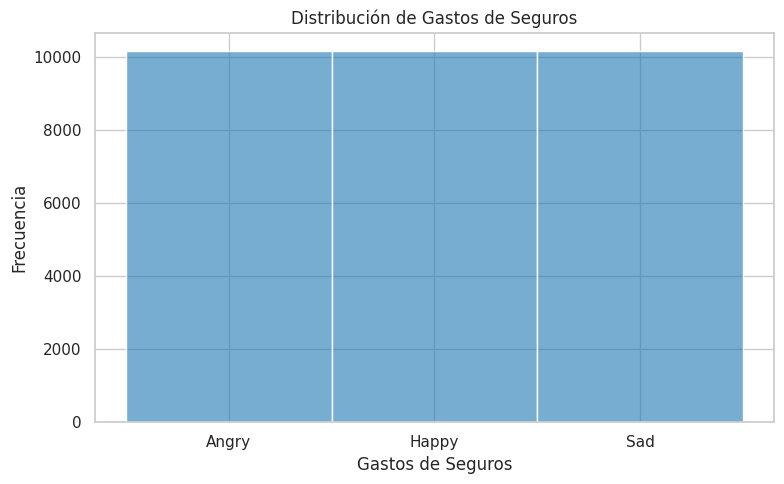

In [82]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    df_balanced['Emotion'],
    color='#1f77b4',
    alpha=0.6,
    ax=ax
  )

ax.set_title("Distribución de Gastos de Seguros")
ax.set_xlabel("Gastos de Seguros")
ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Inspeccion de caracteristicas de las imagenes

In [83]:
dimensiones = []
formatos_color = []

for ruta in df_balanced['Ruta']:
    try:
        with Image.open(ruta) as img:
            dimensiones.append(img.size)
            formatos_color.append(img.mode)
    except Exception as e:
        continue

conteo_dimensiones = Counter(dimensiones)
conteo_formatos = Counter(formatos_color)

print("Resolucion:")
for (ancho, alto), cantidad in conteo_dimensiones.items():
    porcentaje = (cantidad / len(df_balanced)) * 100
    print(f"  • {ancho} x {alto} píxeles: {cantidad} imágenes ({porcentaje:.2f}%)")

print("\nFormato de color:")
for modo, cantidad in conteo_formatos.items():
    porcentaje = (cantidad / len(df_balanced)) * 100
    if modo == 'L':
        descripcion = "Escala de grises (1 canal / Grayscale)"
    elif modo == 'RGB':
        descripcion = "Color verdadero (3 canales / RGB)"
    else:
        descripcion = f"Otro modo ({modo})"

    print(f"  • {descripcion}: {cantidad} imágenes ({porcentaje:.2f}%)")

Resolucion:
  • 48 x 48 píxeles: 29624 imágenes (97.31%)
  • 640 x 640 píxeles: 502 imágenes (1.65%)
  • 5760 x 3840 píxeles: 3 imágenes (0.01%)
  • 3555 x 2370 píxeles: 1 imágenes (0.00%)
  • 6000 x 5709 píxeles: 1 imágenes (0.00%)
  • 6039 x 4026 píxeles: 1 imágenes (0.00%)
  • 6928 x 8660 píxeles: 2 imágenes (0.01%)
  • 6338 x 4225 píxeles: 1 imágenes (0.00%)
  • 6000 x 4000 píxeles: 13 imágenes (0.04%)
  • 5536 x 4160 píxeles: 1 imágenes (0.00%)
  • 4000 x 6000 píxeles: 18 imágenes (0.06%)
  • 6016 x 4016 píxeles: 1 imágenes (0.00%)
  • 4000 x 5334 píxeles: 3 imágenes (0.01%)
  • 4480 x 6720 píxeles: 6 imágenes (0.02%)
  • 4368 x 2912 píxeles: 1 imágenes (0.00%)
  • 5000 x 4502 píxeles: 1 imágenes (0.00%)
  • 4167 x 6250 píxeles: 1 imágenes (0.00%)
  • 8192 x 6144 píxeles: 2 imágenes (0.01%)
  • 5511 x 3674 píxeles: 1 imágenes (0.00%)
  • 6240 x 4160 píxeles: 2 imágenes (0.01%)
  • 8192 x 5461 píxeles: 4 imágenes (0.01%)
  • 5184 x 3456 píxeles: 3 imágenes (0.01%)
  • 2965 x 4448 p

## Estandarizacion de formatos

In [94]:
X_datos = []
y_etiquetas = []

total_img = len(df_balanced)

print(f"Iniciando el procesamiento de {total_img} imágenes...")

start_time = time.time()

for idx, fila in df_balanced.iterrows():
    img = Image.open(fila['Ruta'])

    if img.mode != 'L':
        img = img.convert('L')

    if img.size != (48, 48):
        img = img.resize((48, 48), Image.Resampling.LANCZOS)

    matriz = np.array(img, dtype=np.float32)
    tensor_normalizado = matriz / 255.0
    tensor_final = np.expand_dims(tensor_normalizado, axis=-1)

    X_datos.append(tensor_final)
    y_etiquetas.append(fila['Emotion'])

    if (idx + 1) % 2000 == 0 or (idx + 1) == total_img:
        porcentaje = ((idx + 1) / total_img) * 100
        print(f" Procesadas: {idx + 1}/{total_img} [{porcentaje:.1f}%]")

# Conversión final a NumPy
X = np.array(X_datos, dtype=np.float32)
y = np.array(y_etiquetas)

final_time = time.time()

total_time = final_time - start_time
minutes = int(total_time // 60)
seconds = int(total_time % 60)

print(f"Tiempo total de ejecución: {minutes} min {seconds} seg")
print(f"Imágenes procesadas: {X.shape}")
print(f"Etiquetas guardadas: {y.shape}")

Iniciando el procesamiento de 30444 imágenes...
 Procesadas: 2000/30444 [6.6%]
 Procesadas: 4000/30444 [13.1%]
 Procesadas: 6000/30444 [19.7%]
 Procesadas: 8000/30444 [26.3%]
 Procesadas: 10000/30444 [32.8%]
 Procesadas: 12000/30444 [39.4%]
 Procesadas: 14000/30444 [46.0%]
 Procesadas: 16000/30444 [52.6%]
 Procesadas: 18000/30444 [59.1%]
 Procesadas: 20000/30444 [65.7%]
 Procesadas: 22000/30444 [72.3%]
 Procesadas: 24000/30444 [78.8%]
 Procesadas: 26000/30444 [85.4%]
 Procesadas: 28000/30444 [92.0%]
 Procesadas: 30000/30444 [98.5%]
 Procesadas: 30444/30444 [100.0%]
Tiempo total de ejecución: 2 min 6 seg (126.27 segundos)
Imágenes procesadas: (30444, 48, 48, 1)
Etiquetas guardadas: (30444,)


In [95]:
# Estadísticas del Tensor X (Imágenes preprocesadas)
print("TENSOR DE ENTRADA / IMÁGENES (X):")
print(f"  • Estructura total (Shape): {X.shape}")
print(f"  • Cantidad total de muestras: {X.shape[0]} imágenes")
print(f"  • Dimensión de cada imagen: {X.shape[1]} x {X.shape[2]} píxeles")
print(f"  • Canales de color ajustados: {X.shape[3]} (1 = Escala de grises pura)")
print(f"  • Tipo de datos en memoria (Dtype): {X.dtype}")
print(f"  • Rango de los píxeles: Mínimo = {X.min():.2f} | Máximo = {X.max():.2f}")
print(f"  • Peso total en memoria RAM: {X.nbytes / (1024**2):.2f} MB")

# Estadísticas del Vector y (Etiquetas/Clases)
print("\nVECTOR DE SALIDA / ETIQUETAS (y):")
print(f"  • Estructura total (Shape): {y.shape}")
print(f"  • Tipo de dato (Dtype): {y.dtype}")

TENSOR DE ENTRADA / IMÁGENES (X):
  • Estructura total (Shape): (30444, 48, 48, 1)
  • Cantidad total de muestras: 30444 imágenes
  • Dimensión de cada imagen: 48 x 48 píxeles
  • Canales de color ajustados: 1 (1 = Escala de grises pura)
  • Tipo de datos en memoria (Dtype): float32
  • Rango de los píxeles: Mínimo = 0.00 | Máximo = 1.00
  • Peso total en memoria RAM: 267.57 MB

VECTOR DE SALIDA / ETIQUETAS (y):
  • Estructura total (Shape): (30444,)
  • Tipo de dato (Dtype): <U5


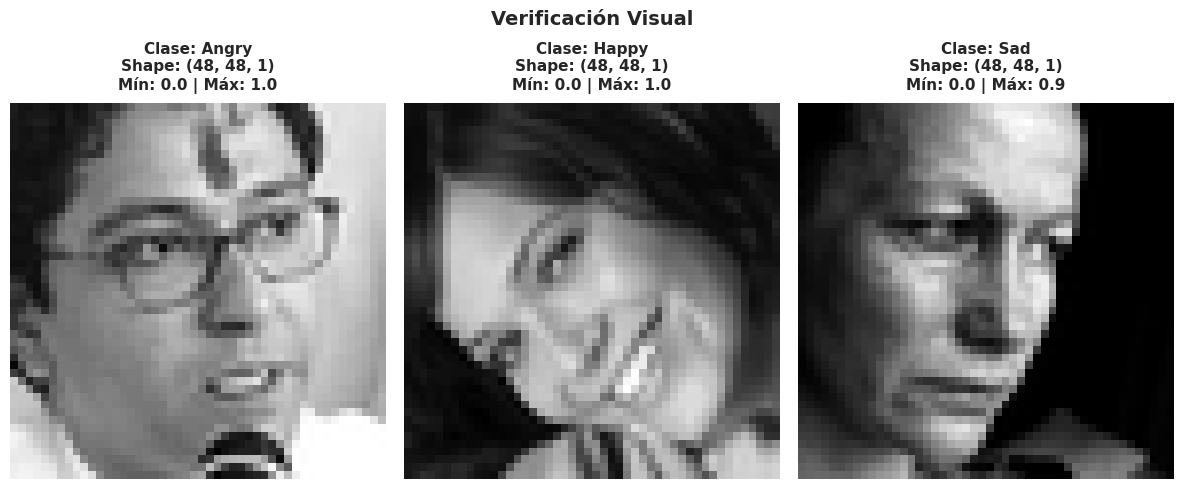

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

clases_unicas = np.unique(y)

for i, emocion in enumerate(clases_unicas):
    indices_clase = np.where(y == emocion)[0]

    indice_aleatorio = np.random.choice(indices_clase)

    tensor_img = X[indice_aleatorio]

    img_mostrar = np.squeeze(tensor_img)

    axes[i].imshow(img_mostrar, cmap='gray')
    axes[i].axis('off')

    axes[i].set_title(
        f"Clase: {emocion}\n"
        f"Shape: {tensor_img.shape}\n"
        f"Mín: {tensor_img.min():.1f} | Máx: {tensor_img.max():.1f}",
        fontsize=11,
        fontweight='bold',
        pad=10
    )

plt.suptitle("Verificación Visual", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()